# Vehicle Insurance Claim Fraud Detection

## About the Dataset
This project uses the Vehicle Insurance Claim Fraud Detection dataset (`fraud_oracle.csv`) from Kaggle. Each row is one vehicle insurance claim, recorded between 1994 and 1996.

- **Size:** 15,420 claims and 33 columns.
- **Target column:** `FraudFound_P`, where 1 means the claim was fraud and 0 means it was genuine.
- **Fraud share:** 923 claims (about 6%) are fraud, so the data is highly imbalanced.

The columns fall into four groups:

- **Accident details:** month, day, area, who was at fault, police report, witness.
- **Policy holder details:** age, sex, marital status, past claims, address change.
- **Vehicle details:** make, category, price, age of vehicle.
- **Policy details:** policy type, base policy, deductible, agent type, days since the policy started.

## Objective
The aim is to detect fraudulent insurance claims. The project covers data cleaning, exploratory analysis, feature engineering, anomaly detection with Isolation Forest, and supervised models for comparison.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\sreya\Downloads\archive (2)\fraud_oracle.csv")
df.head(10)

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
5,Oct,4,Friday,Honda,Urban,Wednesday,Nov,1,Male,Single,...,5 years,21 to 25,No,No,External,3 to 5,no change,1 vehicle,1994,Collision
6,Feb,1,Saturday,Honda,Urban,Monday,Feb,3,Male,Married,...,7 years,36 to 40,No,No,External,1 to 2,no change,1 vehicle,1994,Collision
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
8,Dec,4,Saturday,Honda,Urban,Wednesday,Dec,5,Male,Single,...,6 years,31 to 35,No,Yes,External,3 to 5,no change,1 vehicle,1994,Collision
9,Apr,3,Tuesday,Ford,Urban,Wednesday,Apr,3,Male,Married,...,more than 7,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,All Perils


In [7]:
pd.set_option('display.max_columns', None)
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [4]:
df.shape

(15420, 33)

It has 15,420 rows and 33 columns. Each row is one vehicle insurance claim, and each column is a detail about the claim, the policy holder or the vehicle.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

The dataset has 33 columns: 24 are text (object) columns and 9 are numeric (int64) columns. Every column has 15,420 non-null values, so there are no blank cells. Most of the information is categorical, such as vehicle make, policy type and fault. `FraudFound_P` is the target column, where 1 means fraud and 0 means a genuine claim.

In [8]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

All 33 columns show 0 missing values, so the dataset has no blank cells. This does not confirm the data is fully clean, because missing information can also be stored as a placeholder such as 0 or "none". We will check for that when we look at the unique values of each column.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique().to_frame("No. of unique values")

,No. of unique values
Month,12
WeekOfMonth,5
DayOfWeek,7
Make,19
AccidentArea,2
DayOfWeekClaimed,8
MonthClaimed,13
WeekOfMonthClaimed,5
Sex,2
MaritalStatus,4


Most columns have only 2 to 19 different values, which confirms the data is mainly categorical. Three points stand out:

- `PolicyNumber` has 15,420 unique values, one for every row. It is only a serial number and gives no information about fraud, so it will be dropped.
- `DayOfWeekClaimed` has 8 values, but a week has only 7 days. `MonthClaimed` has 13 values, but a year has only 12 months. Each column has one invalid entry that needs checking.
- `Age` has 66 different values and is the only column with a wide numeric range.

In [11]:
print(df['DayOfWeekClaimed'].unique())
print(df['MonthClaimed'].unique())

['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 '0']
['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 '0']


In [12]:
df.loc[(df['DayOfWeekClaimed'] == '0') | (df['MonthClaimed'] == '0')]

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,0,Policy Holder,Sedan - All Perils,Sedan,more than 69000,0,1517,15,400,2,more than 30,none,none,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils


In [15]:
for i in df.columns:
    print(df[i].value_counts())
    print("\n") 

Month
Jan    1411
May    1367
Mar    1360
Jun    1321
Oct    1305
Dec    1285
Apr    1280
Feb    1266
Jul    1257
Sep    1240
Nov    1201
Aug    1127
Name: count, dtype: int64


WeekOfMonth
3    3640
2    3558
4    3398
1    3187
5    1637
Name: count, dtype: int64


DayOfWeek
Monday       2616
Friday       2445
Tuesday      2300
Thursday     2173
Wednesday    2159
Saturday     1982
Sunday       1745
Name: count, dtype: int64


Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64


AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64


DayOfWeekClaimed
Monday       3757
Tuesday      3375
Wednesday    2951
Thursday     2660
Friday       2497
Saturday      1

In [16]:
print("Rows with Age = 0:", (df['Age'] == 0).sum())

Rows with Age = 0: 320


In [17]:
print(df.loc[df['Age'] == 0, 'AgeOfPolicyHolder'].value_counts())

AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64


There are 320 rows where `Age` is 0, and all of them belong to the "16 to 17" age band. An age of 0 is not possible for a policy holder, so 0 is a placeholder for a missing age. Because every one of these rows falls in the same band, we know these are the youngest policy holders. The data is from the United States, where the driving age is 16 in most states, so we will replace 0 with 16 in the cleaning step.

In [18]:
# For each age band, show the lowest and highest actual Age
df.groupby('AgeOfPolicyHolder')['Age'].agg(['count', 'min', 'max'])

,count,min,max
AgeOfPolicyHolder,,,
16 to 17,320,0,0
18 to 20,15,16,17
21 to 25,108,18,20
26 to 30,613,21,25
31 to 35,5593,26,35
36 to 40,4043,36,45
41 to 50,2828,46,55
51 to 65,1392,56,65
over 65,508,66,80


Each age band covers one continuous range of `Age` with no overlap, so both columns describe the same information: the age of the policy holder. However, the band labels do not match the real ages. For example, the "18 to 20" band holds people aged 16 to 17, and the "36 to 40" band holds people aged 36 to 45. Because the labels are unreliable and the information is repeated, we will keep the numeric `Age` column and drop `AgeOfPolicyHolder` in the cleaning step.

In [21]:
# Remove the row where the claim day is '0' (index 1516)
df = df[df['DayOfWeekClaimed'] != '0']

In [22]:
# Reset the row numbers after removing the row
df = df.reset_index(drop=True)

In [23]:
# Check the new size
df.shape

(15419, 33)

In [24]:
df['Age'] = df['Age'].replace(0, 16)

In [25]:
# Confirm no zero ages remain and check the new lowest age
print("Rows with Age = 0:", (df['Age'] == 0).sum())
print("Minimum Age:", df['Age'].min())

Rows with Age = 0: 0
Minimum Age: 16


In [26]:
# Correct the spelling mistakes in the Make column
df['Make'] = df['Make'].replace({'Accura': 'Acura',
                                 'Nisson': 'Nissan',
                                 'Porche': 'Porsche',
                                 'Mecedes': 'Mercedes'})

# Check the corrected names
df['Make'].unique()

array(['Honda', 'Toyota', 'Ford', 'Mazda', 'Chevrolet', 'Pontiac',
       'Acura', 'Dodge', 'Mercury', 'Jaguar', 'Nissan', 'VW', 'Saab',
       'Saturn', 'Porsche', 'BMW', 'Mercedes', 'Ferrari', 'Lexus'],
      dtype=object)

In [27]:
# Drop PolicyNumber and AgeOfPolicyHolder 
df.drop(['PolicyNumber', 'AgeOfPolicyHolder'], axis=1, inplace=True)

# Check the new size
df.shape

(15419, 31)

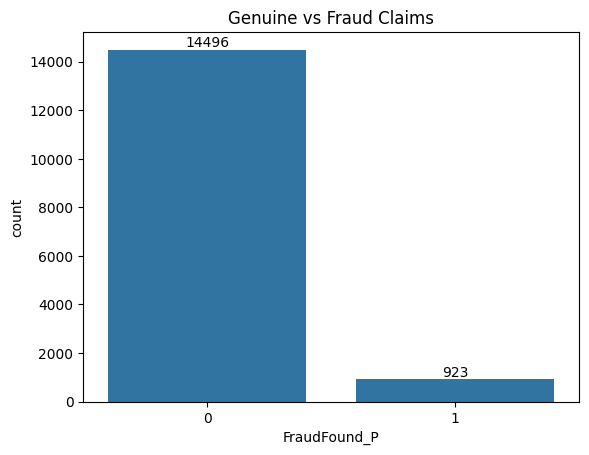

In [31]:
# Count plot of the target column (0 = genuine, 1 = fraud)
ax = sns.countplot(x='FraudFound_P', data=df)

ax.bar_label(ax.containers[0])

plt.title("Genuine vs Fraud Claims")
plt.show()

Out of 15,419 claims, 14,496 are genuine and 923 are fraud. Fraud makes up about 6% of the data, which means there are roughly 16 genuine claims for every fraud claim. The dataset is highly imbalanced. Because of this, accuracy alone would be misleading: a model that calls every claim genuine would still be 94% accurate while catching no fraud. We will judge the models on recall and precision for the fraud class.

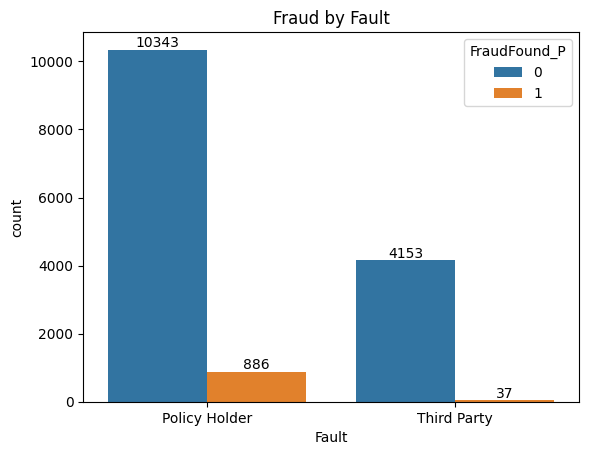

In [33]:
# Count of genuine and fraud claims for each fault type
ax = sns.countplot(x='Fault', hue='FraudFound_P', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud by Fault")
plt.show()

`Fault` shows who caused the accident. When the policy holder was at fault, 886 out of 11,229 claims were fraud (7.9%). When a third party was at fault, only 37 out of 4,190 claims were fraud (0.9%). About 96% of all fraud claims (886 of 923) come from accidents where the policy holder was at fault. This makes `Fault` one of the strongest indicators of fraud in the dataset. A likely reason is that a self-caused accident is easier to fake, because no other driver or insurer is involved to confirm what happened.

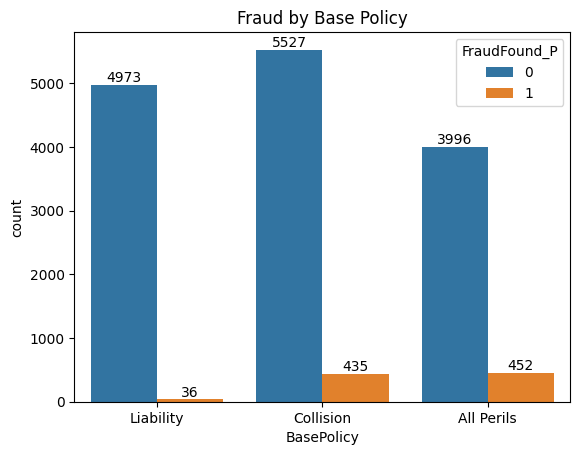

In [34]:
# Count of genuine and fraud claims for each base policy
ax = sns.countplot(x='BasePolicy', hue='FraudFound_P', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud by Base Policy")
plt.show()

Fraud differs sharply across the three policy types. Liability has only 36 fraud claims out of 5,009 (0.7%), Collision has 435 out of 5,962 (7.3%), and All Perils has 452 out of 4,448 (10.2%). All Perils has the fewest claims but the most fraud. The pattern follows what each policy pays for: Liability only covers damage caused to other people, so the policy holder gains little from a false claim. Collision and All Perils pay for the policy holder's own vehicle, which gives a direct financial reason to fake or exaggerate a claim.

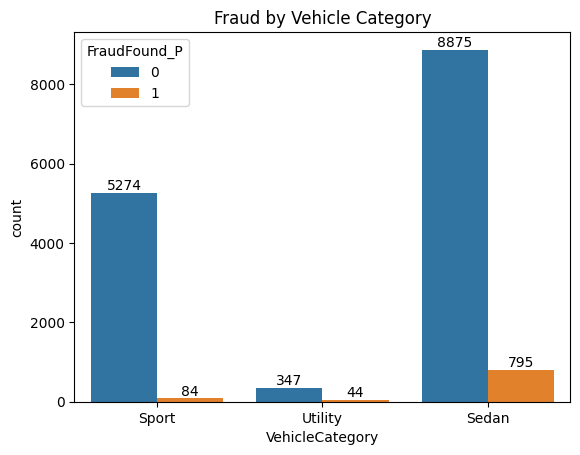

In [35]:
# Count of genuine and fraud claims for each vehicle category
ax = sns.countplot(x='VehicleCategory', hue='FraudFound_P', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud by Vehicle Category")
plt.show()

In [36]:
# Cross table: how each policy type is spread across the vehicle categories
pd.crosstab(df['PolicyType'], df['VehicleCategory'])

VehicleCategory,Sedan,Sport,Utility
PolicyType,,,
Sedan - All Perils,4086,0,0
Sedan - Collision,5584,0,0
Sedan - Liability,0,4987,0
Sport - All Perils,0,22,0
Sport - Collision,0,348,0
Sport - Liability,0,1,0
Utility - All Perils,0,0,340
Utility - Collision,0,0,30
Utility - Liability,0,0,21


A cross table counts how many claims fall in each combination of two columns. Here the rows are the policy types and the columns are the vehicle categories.

- Each policy type has claims in only one vehicle category and zeros in the others.
- All 4,987 "Sedan - Liability" policies are recorded under the Sport category, not Sedan.
- Because of this, the Sport category is made up almost entirely of liability policies, which have very little fraud. That is why Sport showed a low fraud rate in the previous chart.

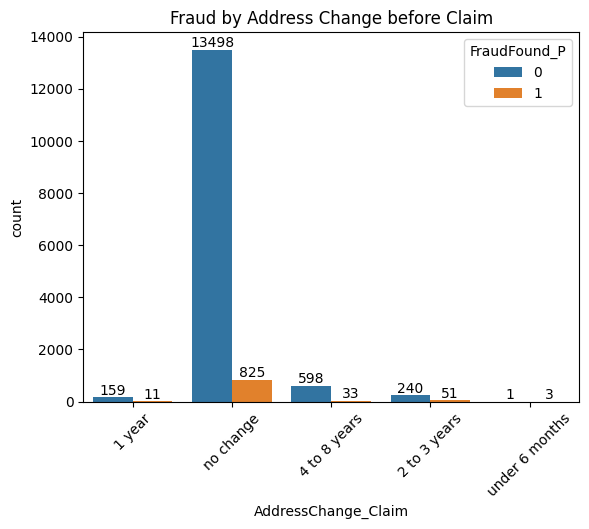

In [37]:
# Count of genuine and fraud claims by how recently the address changed
ax = sns.countplot(x='AddressChange_Claim', hue='FraudFound_P', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud by Address Change before Claim")
plt.xticks(rotation=45)
plt.show()

Most policy holders (14,323) never changed their address, and their fraud rate is 5.8%. Fraud is much higher for those who changed their address 2 to 3 years before the claim (17.5%) and under 6 months before the claim (3 out of 4 claims). So a recent address change is a warning sign of fraud.

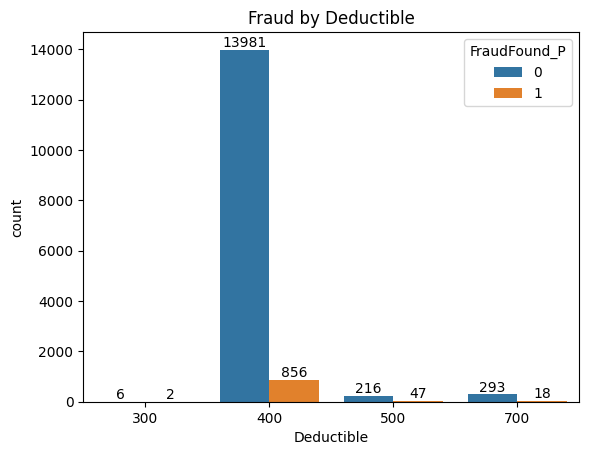

In [38]:
# Count of genuine and fraud claims for each deductible amount
ax = sns.countplot(x='Deductible', hue='FraudFound_P', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Fraud by Deductible")
plt.show()

Almost all claims (14,837) have the standard deductible of 400, with a fraud rate of 5.8%. Claims with a deductible of 500 show a much higher fraud rate of 17.9% (47 out of 263). The 300 group has 2 fraud out of only 8 claims, which is too small to conclude from. So an unusual deductible, especially 500, is a warning sign of fraud.

In [42]:
# Skewness of each numeric column (0 = symmetric, above +0.5 or below -0.5 = skewed)
df.skew(numeric_only=True)

WeekOfMonth           0.115323
WeekOfMonthClaimed    0.158152
Age                   0.611563
FraudFound_P          3.711019
RepNumber             0.006720
Deductible            6.078591
DriverRating          0.009203
Year                  0.245581
dtype: float64

Most columns have skewness close to 0, so they are balanced. `Age` (0.61) is slightly right-skewed. `Deductible` (6.08) and `FraudFound_P` (3.71) are highly skewed because one value dominates each of them. No transformation is needed, as tree-based models like Isolation Forest are not affected by skewness.

## Feature Engineering

In [43]:
# 1. Was the accident on a weekend? (1 = yes, 0 = no)
df['WeekendAccident'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

# 2. Did the policy holder change address before the claim? (1 = yes, 0 = no)
df['AddressChanged'] = (df['AddressChange_Claim'] != 'no change').astype(int)

# 3. No police report and no witness? (1 = claim has no outside proof, 0 = has proof)
df['NoProof'] = ((df['PoliceReportFiled'] == 'No') & (df['WitnessPresent'] == 'No')).astype(int)

# See the new columns
df[['WeekendAccident', 'AddressChanged', 'NoProof']].head()

,WeekendAccident,AddressChanged,NoProof
0,0,1,1
1,0,0,0
2,0,0,1
3,1,0,0
4,0,0,1


In [44]:
# 4. Did the accident happen within 30 days of buying the policy? (1 = yes, 0 = no)
df['NewPolicy'] = (df['Days_Policy_Accident'] != 'more than 30').astype(int)

# 5. Is this the policy holder's first claim? (1 = yes, 0 = no)
df['FirstClaim'] = (df['PastNumberOfClaims'] == 'none').astype(int)

# Check the new size
df.shape

(15419, 36)

Five new columns were created from the existing data, each holding 1 (yes) or 0 (no):

- `WeekendAccident`: the accident happened on a Saturday or Sunday.
- `AddressChanged`: the policy holder changed address before the claim.
- `NoProof`: the claim has no police report and no witness.
- `NewPolicy`: the accident happened within 30 days of buying the policy.
- `FirstClaim`: the policy holder has no past claims.

These turn patterns from the analysis into simple flags the model can use. The dataset now has 36 columns.

In [45]:
# Drop ID and calendar columns that carry little information about fraud
df.drop(['RepNumber', 'Year', 'Month', 'WeekOfMonth', 'DayOfWeek',
         'MonthClaimed', 'WeekOfMonthClaimed', 'DayOfWeekClaimed'], axis=1, inplace=True)

# Check the new size
df.shape

(15419, 28)

In [46]:
from sklearn.preprocessing import OrdinalEncoder

OE = OrdinalEncoder()
for i in df.columns:
    if df[i].dtypes == 'object':
        df[i] = OE.fit_transform(df[i].values.reshape(-1, 1))

df.head()

,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,BasePolicy,WeekendAccident,AddressChanged,NoProof,NewPolicy,FirstClaim
0,6.0,1.0,0.0,2.0,21,0.0,5.0,1.0,5.0,0,300,1,3.0,2.0,3.0,1.0,0.0,0.0,0.0,3.0,0.0,2.0,2.0,0,1,1,0,1
1,6.0,1.0,1.0,2.0,34,0.0,4.0,1.0,5.0,0,400,4,3.0,2.0,3.0,4.0,1.0,0.0,0.0,3.0,3.0,0.0,1.0,0,0,0,0,1
2,6.0,1.0,1.0,1.0,47,0.0,4.0,1.0,5.0,0,400,3,3.0,2.0,0.0,5.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,0,0,1,0,0
3,17.0,0.0,1.0,1.0,65,1.0,2.0,1.0,0.0,0,400,2,3.0,2.0,0.0,6.0,1.0,0.0,0.0,2.0,3.0,0.0,2.0,1,0,0,0,0
4,6.0,1.0,0.0,2.0,27,1.0,4.0,1.0,5.0,0,400,1,3.0,2.0,3.0,3.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,0,0,1,0,1


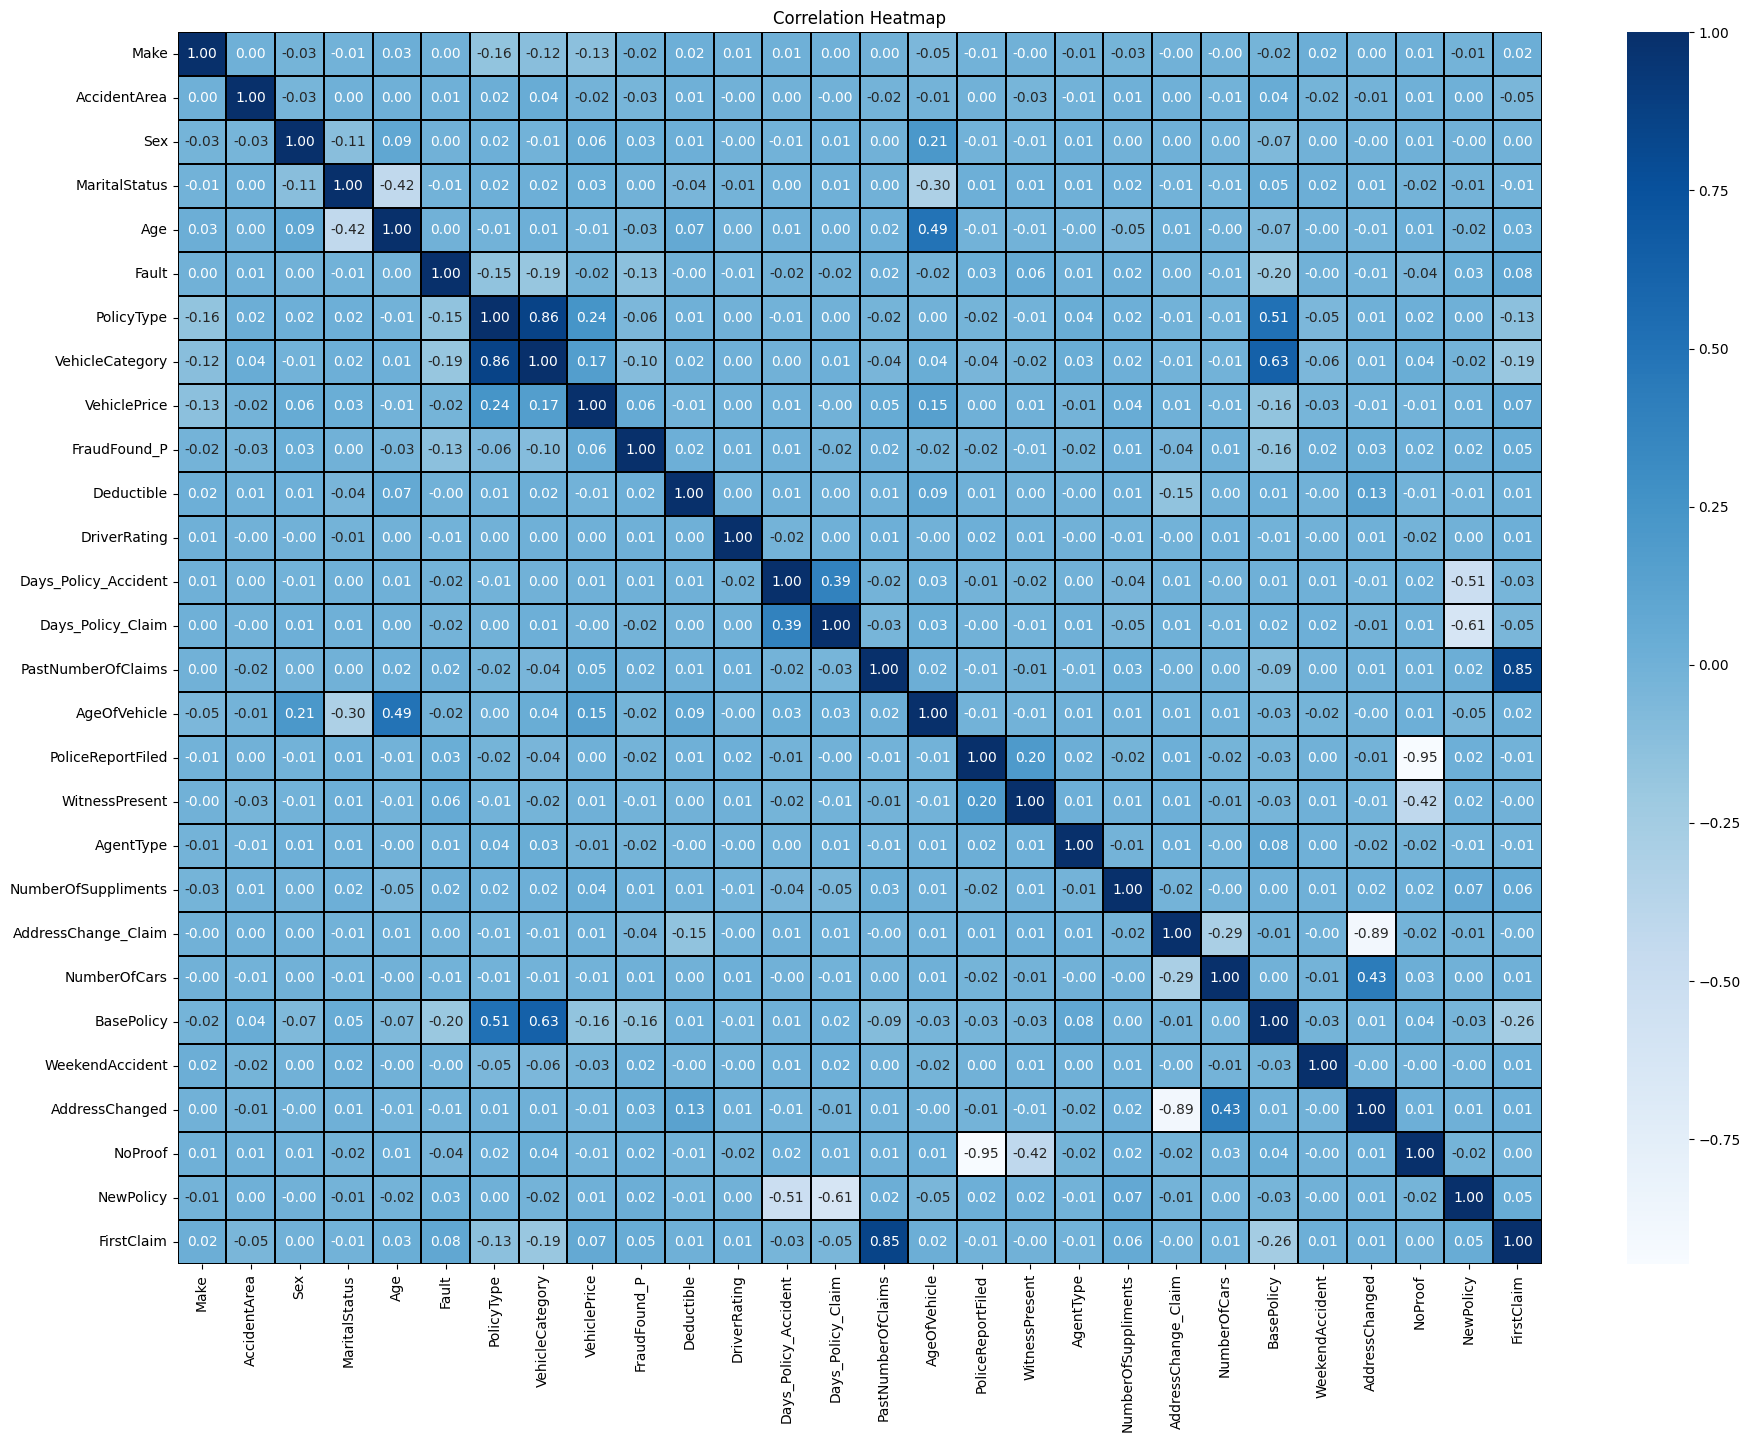

In [47]:
# Correlation matrix of all columns
cor = df.corr()

# Heatmap with the correlation value written in each box
plt.figure(figsize=(22, 16))
sns.heatmap(cor, annot=True, fmt='.2f', cmap='Blues', linewidths=0.1, linecolor='black')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the correlation between every pair of columns. `BasePolicy` (-0.16), `Fault` (-0.13) and `VehicleCategory` (-0.10) have the strongest relation with fraud.

Four pairs of columns are highly correlated (above 0.8), which means they repeat the same information: `PolicyType` with `VehicleCategory`, `NoProof` with `PoliceReportFiled`, `FirstClaim` with `PastNumberOfClaims`, and `AddressChanged` with `AddressChange_Claim`. One column from each pair will be dropped.

`MaritalStatus`, `DriverRating`, `NumberOfCars` and `Days_Policy_Claim` have correlation close to 0 with fraud, so they will also be dropped.

In [49]:
# Drop one column from each highly correlated pair
df.drop(['PolicyType', 'PoliceReportFiled', 'WitnessPresent',
         'PastNumberOfClaims', 'AddressChanged'], axis=1, inplace=True)

# Drop columns with almost no relation to fraud
df.drop(['MaritalStatus', 'DriverRating', 'NumberOfCars', 'Days_Policy_Claim'],
        axis=1, inplace=True)

# Check the final size
df.shape

(15419, 19)

In [50]:
from sklearn.preprocessing import StandardScaler

x = df.drop("FraudFound_P", axis=1)
y = df["FraudFound_P"]

scaler = StandardScaler()
x = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

x.head()

,Make,AccidentArea,Sex,Age,Fault,VehicleCategory,VehiclePrice,Deductible,Days_Policy_Accident,AgeOfVehicle,AgentType,NumberOfSuppliments,AddressChange_Claim,BasePolicy,WeekendAccident,NoProof,NewPolicy,FirstClaim
0,-0.778914,0.339912,-2.317647,-1.513552,-0.610853,1.116812,2.018412,-2.450567,0.054325,-3.332381,-0.126009,0.897423,-6.403549,1.231756,-0.564593,0.178284,-0.106523,1.594924
1,-0.778914,0.339912,0.431472,-0.488180,-0.610853,1.116812,2.018412,-0.175304,0.054325,-0.700961,-0.126009,0.897423,0.247153,-0.046508,-0.564593,-5.609015,-0.106523,1.594924
2,-0.778914,0.339912,0.431472,0.537191,-0.610853,1.116812,2.018412,-0.175304,0.054325,0.176179,-0.126009,0.897423,0.247153,-0.046508,-0.564593,0.178284,-0.106523,-0.626989
3,1.303309,-2.941934,0.431472,1.956936,1.637056,1.116812,-0.702985,-0.175304,0.054325,1.053319,-0.126009,-0.002978,0.247153,1.231756,1.771188,-5.609015,-0.106523,-0.626989
4,-0.778914,0.339912,-2.317647,-1.040303,1.637056,1.116812,2.018412,-0.175304,0.054325,-1.578101,-0.126009,0.897423,0.247153,-0.046508,-0.564593,0.178284,-0.106523,1.594924


In [51]:
from sklearn.ensemble import IsolationForest

# Train the model on the features only (the label y is not used)
# contamination = share of claims we expect to be fraud (about 6%)
iso = IsolationForest(n_estimators=100, contamination=0.06, random_state=42)
iso.fit(x)

# The model returns -1 for an anomaly and 1 for normal
pred_iso = iso.predict(x)

# Convert to our format: 1 = fraud, 0 = genuine
pred_iso = np.where(pred_iso == -1, 1, 0)

# How many claims were flagged as fraud
pd.Series(pred_iso).value_counts()

0    14493
1      926
Name: count, dtype: int64

In [52]:
from sklearn.metrics import confusion_matrix, classification_report

# Compare Isolation Forest flags with the real fraud label
print(confusion_matrix(y, pred_iso))
print(classification_report(y, pred_iso))

[[13643   853]
 [  850    73]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     14496
           1       0.08      0.08      0.08       923

    accuracy                           0.89     15419
   macro avg       0.51      0.51      0.51     15419
weighted avg       0.89      0.89      0.89     15419



The model's flags were compared with the real fraud label.

- It caught 73 of the 923 fraud claims, so recall is 8%.
- Only 73 of its 926 flags were real fraud, so precision is 8%.
- Accuracy is 89%, but this is misleading because most claims are genuine.

Isolation Forest looks for unusual claims, but fraud claims in this dataset look very similar to genuine ones. So the model performs only slightly better than random flagging.

In [53]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y)

print(x_train.shape, x_test.shape)
print(y_test.value_counts())

(10793, 18) (4626, 18)
FraudFound_P
0    4349
1     277
Name: count, dtype: int64


#### Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' makes the model pay more attention to the rare fraud class
LR = LogisticRegression(class_weight='balanced', max_iter=1000)
LR.fit(x_train, y_train)

# Predict on the test set and compare with the real label
predLR = LR.predict(x_test)
print(confusion_matrix(y_test, predLR))
print(classification_report(y_test, predLR))

[[2791 1558]
 [  44  233]]
              precision    recall  f1-score   support

           0       0.98      0.64      0.78      4349
           1       0.13      0.84      0.23       277

    accuracy                           0.65      4626
   macro avg       0.56      0.74      0.50      4626
weighted avg       0.93      0.65      0.74      4626



In [55]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' gives more weight to fraud; max_depth=8 keeps the trees small
RFC = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=8, random_state=42)
RFC.fit(x_train, y_train)

# Predict on the test set and compare with the real label
predRFC = RFC.predict(x_test)
print(confusion_matrix(y_test, predRFC))
print(classification_report(y_test, predRFC))

[[2693 1656]
 [  27  250]]
              precision    recall  f1-score   support

           0       0.99      0.62      0.76      4349
           1       0.13      0.90      0.23       277

    accuracy                           0.64      4626
   macro avg       0.56      0.76      0.50      4626
weighted avg       0.94      0.64      0.73      4626



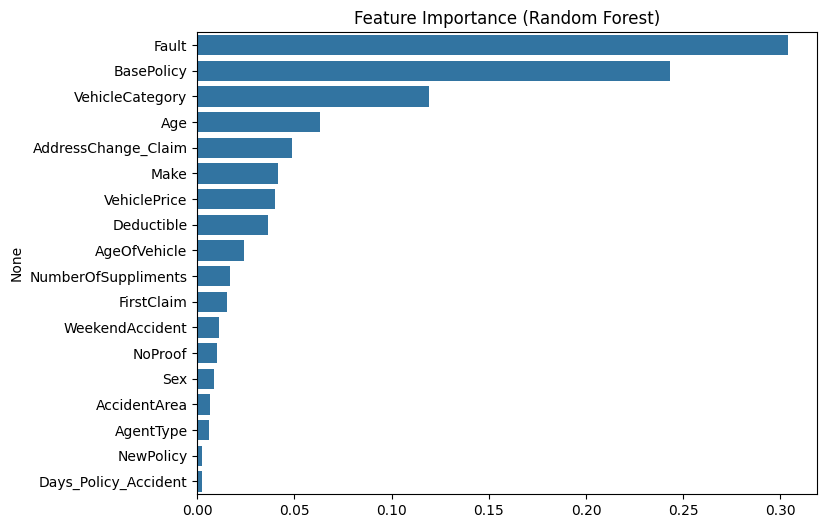

Fault                   0.304
BasePolicy              0.243
VehicleCategory         0.119
Age                     0.063
AddressChange_Claim     0.049
Make                    0.041
VehiclePrice            0.040
Deductible              0.037
AgeOfVehicle            0.024
NumberOfSuppliments     0.017
FirstClaim              0.015
WeekendAccident         0.011
NoProof                 0.010
Sex                     0.009
AccidentArea            0.006
AgentType               0.006
NewPolicy               0.002
Days_Policy_Accident    0.002
dtype: float64


In [56]:
# Importance of each feature in the Random Forest model
importance = pd.Series(RFC.feature_importances_, index=x.columns).sort_values(ascending=False)

# Bar chart of feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

print(importance.round(3))

The chart shows which features the Random Forest relied on most. `Fault` (30%), `BasePolicy` (24%) and `VehicleCategory` (12%) together account for about two-thirds of the model's decisions. This matches the charts from the exploratory analysis, where these columns showed the largest differences in fraud rate. `Age`, `AddressChange_Claim`, `Make`, `VehiclePrice` and `Deductible` add a smaller contribution, and the remaining features matter very little.

In [58]:
from sklearn.tree import DecisionTreeClassifier

# A single tree; max_depth=6 keeps it small so it does not memorise the training data
DT = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)
DT.fit(x_train, y_train)

# Predict on the test set and compare with the real label
predDT = DT.predict(x_test)
print(confusion_matrix(y_test, predDT))
print(classification_report(y_test, predDT))

[[2573 1776]
 [  16  261]]
              precision    recall  f1-score   support

           0       0.99      0.59      0.74      4349
           1       0.13      0.94      0.23       277

    accuracy                           0.61      4626
   macro avg       0.56      0.77      0.48      4626
weighted avg       0.94      0.61      0.71      4626



In [59]:
from sklearn.svm import SVC

# class_weight='balanced' gives more weight to the rare fraud class
svc = SVC(class_weight='balanced', random_state=42)
svc.fit(x_train, y_train)

# Predict on the test set and compare with the real label
predsvc = svc.predict(x_test)
print(confusion_matrix(y_test, predsvc))
print(classification_report(y_test, predsvc))

[[2754 1595]
 [  32  245]]
              precision    recall  f1-score   support

           0       0.99      0.63      0.77      4349
           1       0.13      0.88      0.23       277

    accuracy                           0.65      4626
   macro avg       0.56      0.76      0.50      4626
weighted avg       0.94      0.65      0.74      4626



In [60]:
from sklearn.metrics import precision_score, recall_score

# Recall and precision for the fraud class, for each model
summary = pd.DataFrame({
    'Model': ['Isolation Forest', 'Logistic Regression', 'Random Forest', 'Decision Tree', 'SVC'],
    'Fraud Recall': [recall_score(y, pred_iso), recall_score(y_test, predLR), recall_score(y_test, predRFC),
                     recall_score(y_test, predDT), recall_score(y_test, predsvc)],
    'Fraud Precision': [precision_score(y, pred_iso), precision_score(y_test, predLR), precision_score(y_test, predRFC),
                        precision_score(y_test, predDT), precision_score(y_test, predsvc)]
}).round(2)

summary

,Model,Fraud Recall,Fraud Precision
0,Isolation Forest,0.08,0.08
1,Logistic Regression,0.84,0.13
2,Random Forest,0.90,0.13
3,Decision Tree,0.94,0.13
4,SVC,0.88,0.13


####  Model Comparison
The table compares how well each model detects the fraud class.

- **Isolation Forest** (unsupervised) caught only 8% of fraud, with 8% precision.
- **The four supervised models** caught between 84% and 94% of fraud, all with 13% precision.
- **Decision Tree** has the highest recall (94%), followed by Random Forest (90%), SVC (88%) and Logistic Regression (84%).

The supervised models are far better than Isolation Forest because they learn from the fraud label. Their precision of 13% means about 1 in 8 flagged claims is real fraud, so the models work best as a screening tool that selects claims for manual checking. Isolation Forest was evaluated on the full dataset, and the supervised models on the 30% test set.

#### Conclusion
This project analysed 15,419 vehicle insurance claims to detect fraud. About 6% of the claims (923) were fraud.

**Data preparation:** The dataset had no blank cells, but it had hidden problems. One invalid row was removed, 319 placeholder ages of 0 were replaced with 16, four misspelt car makes were corrected, and repeated or unrelated columns were dropped. Five new features were created, and the final dataset had 18 features.

**Key findings from the analysis:**
- Fraud is about nine times more common when the policy holder is at fault (7.9%) than when a third party is at fault (0.9%).
- All Perils (10.2%) and Collision (7.3%) policies have far more fraud than Liability policies (0.7%).
- A recent address change and a non-standard deductible are warning signs of fraud.
- Age has very little relation to fraud.

**Model results:** Isolation Forest caught only 8% of fraud, because fraud claims in this data look very similar to genuine claims and do not stand out as anomalies. The supervised models caught 84% to 94% of fraud. Decision Tree performed best with 94% recall, and `Fault`, `BasePolicy` and `VehicleCategory` were the most important features.

**Conclusion:** For this dataset, supervised models are much more effective than anomaly detection. With a precision of 13%, the models are best used to shortlist suspicious claims for investigators, which reduces the number of claims to check while still catching most of the fraud.